<a href="https://colab.research.google.com/github/catastropiyush/EquiP/blob/main/EquiP_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **EquiP: Machine Learning Model for Predicting Equilibrium Plateau Pressure of Metal Compositions**

The equilibrium plateau pressure (Peq) is a critical thermodynamic parameter, as it defines the conditions under which hydrogen absorption and desorption occur, directly influencing operating conditions of the system. However, experimentally evaluating every possible alloying combination is impractical due to the combinatorial explosion of candidate systems. Particularly, determining Van’t Hoff plots (P eq vs. 1/T) typically requires multiple pressure-temperature measurements.

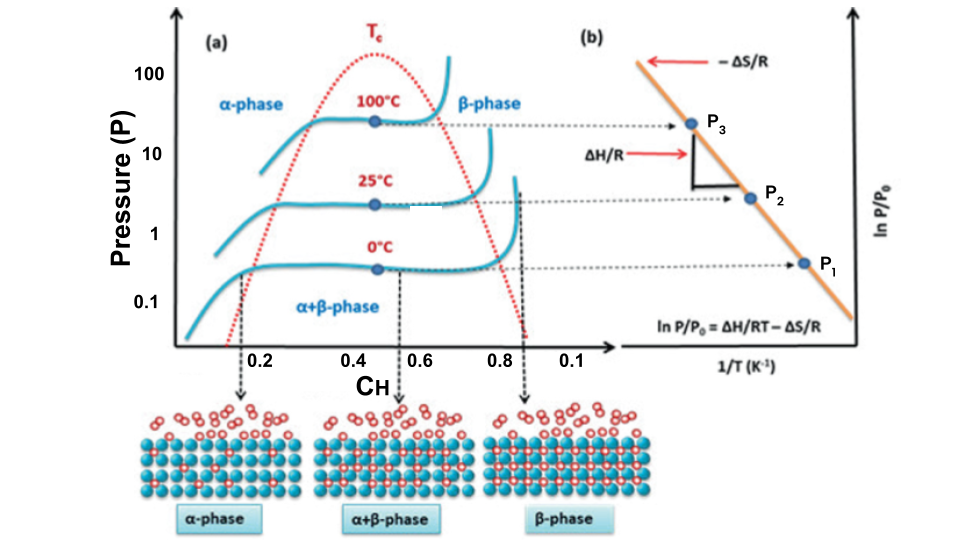

We present EquiP, an ML model trained to predict the equilibrium plateau pressure of metal compositions as a function of temperature. Through EquiP, we have also demonstrated how the incorporation of domain-informed features such as, operating conditions, hydride characteristics, and XRD information brings model predictability closer to experimental results, even with limited data. For example, including temperature as feature not only enhances model
accuracy but also enables determination of Van’t Hoff plots (Peq vs 1/T), facilitating rapid estimation of enthalpy and entropy of hydride formation.

# Step 1: Import Required Libraries
### The notebook starts by importing all the necessary Python libraries for:
### Data handling → pandas, numpy
### Machine learning → scikit-learn"
### Visualization → matplotlib, shap, plotly"


In [21]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable InRelease [3,917 B]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [70.9 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,070 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,614 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd6

In [26]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

In [27]:
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

In [1]:
!git clone https://github.com/ashwinidverma/EquiP.git

Cloning into 'EquiP'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 55 (delta 12), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 12.57 MiB | 9.62 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate, KFold, ShuffleSplit, GridSearchCV, learning_curve
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings('ignore')

# Step 2 : Load and Prepare Dataset
### Load input CSV file (EQUIP_Input_3.csv).
### Select the features and target variable (Ln(P)_Mpa).
### Standardize (normalize) feature values using StandardScaler.
### Split data into training (80%) and test (20%) sets.

In [3]:

data = pd.read_csv('/content/EquiP/Data/EQUIP_Input.csv')
Features = ['Temperature', 'CR', 'Mass', 'FIE', 'BM', 'HF', 'MV', 'M-H_Bond', 'M-H_Eng',
            'formation_H', 'vol_H', 'vol_diff', 'EN.Diff', 'Atomic.Size.Diff', 'dSmix']
scaler = StandardScaler()
data[Features] = scaler.fit_transform(data[Features])
X = data[Features]
y = data["Ln(P)_Mpa"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [4]:
data

,no,SrNo,PDF_name,Type,Compostion,Class,composition_final,Element,Fraction,Frac,...,en_at_H,formation_M,en_at_M,vol_H,vol_M,vol_diff,EN.Diff,M-H.EN.Diff,Atomic.Size.Diff,dSmix
0,7.0,8,MgSnZn,Lit_PCT,Mg 95 Sn 3 Zn 2,Mg+TM+Ln+,Mg0.95Sn0.03Zn0.02,Mg Sn Zn,0.95 0.03 0.02,0.95 0.03 0.02,...,-3.0775,0.0107,-1.6548,0.996448,44.7960,0.592396,-0.561847,-0.8637,-1.392488,-1.562169
1,8.0,9,MgSnZn,Lit_PCT,Mg 95 Sn 3 Zn 2,Mg+TM+Ln+,Mg0.95Sn0.03Zn0.02,Mg Sn Zn,0.95 0.03 0.02,0.95 0.03 0.02,...,-3.0775,0.0107,-1.6548,0.996448,44.7960,0.592396,-0.561847,-0.8637,-1.392488,-1.562169
2,9.0,10,MgSnZn,Lit_PCT,Mg 95 Sn 3 Zn 2,Mg+TM+Ln+,Mg0.95Sn0.03Zn0.02,Mg Sn Zn,0.95 0.03 0.02,0.95 0.03 0.02,...,-3.0775,0.0107,-1.6548,0.996448,44.7960,0.592396,-0.561847,-0.8637,-1.392488,-1.562169
3,10.0,39,17,PCI,Mg-0.05In,Mg+TM+Ln+,In0.05Mg0.95,Mg In,0.95 0.05,0.95 0.05,...,-3.0700,0.0110,-1.6465,0.809785,43.8840,0.595359,-0.730777,-0.8665,-1.531292,-1.653565
4,11.0,40,17,PCI,Mg-0.05In,Mg+TM+Ln+,In0.05Mg0.95,Mg In,0.95 0.05,0.95 0.05,...,-3.0700,0.0110,-1.6465,0.809785,43.8840,0.595359,-0.730777,-0.8665,-1.531292,-1.653565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
288,217.0,393,244,PCT,(TiZr 0.1 ) 1.1 Cr 1.5 Fe 0.2 Mn 0.3,TM,Cr0.47Fe0.06Mn0.09Ti0.34Zr0.03,Ti Zr Cr Fe Mn,0.34 0.03 0.47 0.06 0.09,0.34 0.03 0.47 0.06 0.09,...,-6.2698,0.0000,-8.8962,0.120542,61.5001,-0.295827,-0.837470,-0.5850,-0.211707,1.100957
289,218.0,394,244,PCT,(TiZr 0.1 ) 1.1 Cr 1.5 Fe 0.2 Mn 0.3,TM,Cr0.47Fe0.06Mn0.09Ti0.34Zr0.03,Ti Zr Cr Fe Mn,0.34 0.03 0.47 0.06 0.09,0.34 0.03 0.47 0.06 0.09,...,-6.2698,0.0000,-8.8962,0.120542,61.5001,-0.295827,-0.837470,-0.5850,-0.211707,1.100957
290,187.0,352,182,PCT,TiZrNbTa,TM,Nb0.25Ta0.25Ti0.25Zr0.25,Ti Zr Nb Ta,0.25 0.25 0.25 0.25,0.25 0.25 0.25 0.25,...,-6.7700,0.0000,-9.6000,-0.375196,29.5075,0.497598,-0.750535,-0.7075,-0.808752,1.573458
291,188.0,353,182,PCT,TiZrNbTa,TM,Nb0.25Ta0.25Ti0.25Zr0.25,Ti Zr Nb Ta,0.25 0.25 0.25 0.25,0.25 0.25 0.25 0.25,...,-6.7700,0.0000,-9.6000,-0.375196,29.5075,0.497598,-0.750535,-0.7075,-0.808752,1.573458


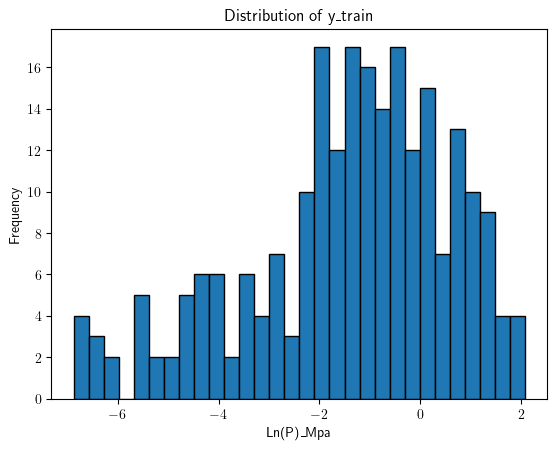

In [28]:
import matplotlib.pyplot as plt
plt.hist(y_train, bins=30, edgecolor='black')
plt.title('Distribution of y_train')
plt.xlabel('Ln(P)_Mpa')
plt.ylabel('Frequency')
plt.show()

In [6]:
display(data.describe())

,no,SrNo,Temperature_in_plot,Pressure_plot,Temperature(oC)_graph,Temperature,Temperature_1,Ln(P)_Mpa,Ln(P)_bar,Pressure(MPa),...,en_at_H,formation_M,en_at_M,vol_H,vol_M,vol_diff,EN.Diff,M-H.EN.Diff,Atomic.Size.Diff,dSmix
count,289.000000,293.000000,293.000000,293.000000,293.000000,2.930000e+02,293.000000,293.000000,293.000000,293.000000,...,293.000000,293.000000,293.000000,2.930000e+02,293.000000,2.930000e+02,2.930000e+02,293.000000,2.930000e+02,2.930000e+02
mean,162.273356,200.703072,2.449549,2.581807,219.921867,9.700242e-17,444.767918,-1.326520,0.980965,1.133208,...,-4.788347,0.003397,-5.537458,-3.395085e-16,52.735294,-4.850121e-17,8.487712e-17,-0.650309,1.333783e-16,1.940048e-16
std,97.361180,159.091052,0.805141,5.840405,158.473995,1.001711e+00,143.230586,1.979791,1.945431,1.734232,...,1.271747,0.004624,2.838350,1.001711e+00,33.886313,1.001711e+00,1.001711e+00,0.158720,1.001711e+00,1.001711e+00
min,3.000000,0.000000,0.202900,-4.132800,0.440000,-1.201292e+00,273.000000,-6.866800,-4.564200,0.000000,...,-6.770000,0.000000,-9.600000,-2.001757e+00,22.524200,-3.345192e+00,-1.447002e+00,-0.910000,-1.531292e+00,-1.653565e+00
25%,75.000000,53.000000,1.671800,0.579400,59.710000,-9.145508e-01,314.000000,-2.286800,0.090000,0.120000,...,-6.016800,0.000000,-8.710000,-7.985795e-01,34.435400,1.470994e-01,-8.374696e-01,-0.838800,-8.714993e-01,-8.333875e-01
50%,164.000000,222.000000,2.689385,1.673200,275.160000,-5.368913e-01,368.000000,-1.073300,1.151300,0.470000,...,-4.683700,0.000000,-5.576300,-1.422153e-01,42.055200,2.881115e-01,-3.188241e-01,-0.595000,-2.117066e-01,-4.007007e-02
75%,248.000000,360.000000,3.187600,3.116800,338.160000,1.043683e+00,594.000000,0.122700,2.422000,1.360000,...,-3.321200,0.009000,-2.145400,6.393140e-01,49.109500,5.890952e-01,1.135359e+00,-0.524500,6.154111e-01,7.573319e-01
max,330.000000,448.000000,3.700900,62.705400,653.000000,1.652135e+00,681.000000,2.072600,4.375200,15.480000,...,-3.010000,0.014000,-1.646500,2.090404e+00,166.075400,6.664571e-01,1.881221e+00,-0.416100,2.119434e+00,1.863559e+00


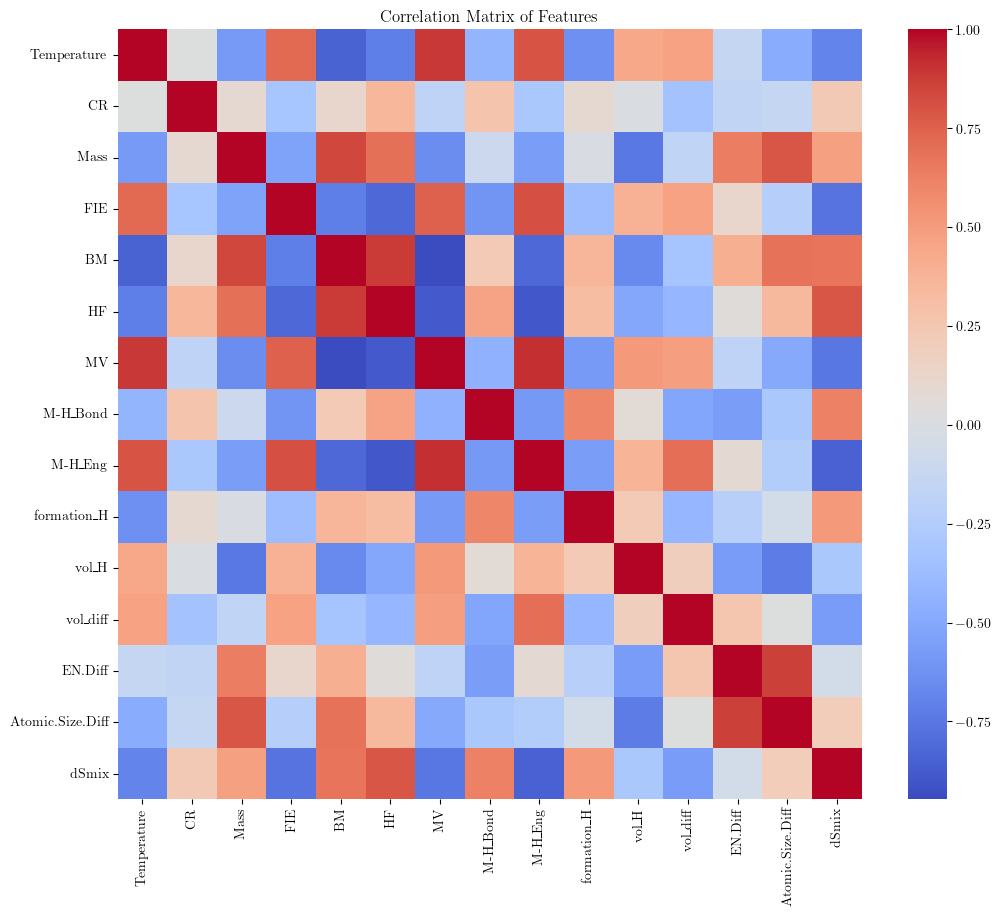

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

In [8]:
correlated_features = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.8: # Adjust threshold as needed
            colname1 = correlation_matrix.columns[i]
            colname2 = correlation_matrix.columns[j]
            correlated_features.add((colname1, colname2, correlation_matrix.iloc[i, j]))

if correlated_features:
    print("Features with high absolute correlation (>0.8):")
    for feature_pair in correlated_features:
        print(f"- {feature_pair[0]} and {feature_pair[1]} (Correlation: {feature_pair[2]:.2f})")
else:
    print("No features with high absolute correlation (>0.8) found.")

Features with high absolute correlation (>0.8):
- MV and BM (Correlation: -0.95)
- BM and Temperature (Correlation: -0.84)
- HF and FIE (Correlation: -0.82)
- MV and Temperature (Correlation: 0.89)
- HF and BM (Correlation: 0.88)
- Atomic.Size.Diff and EN.Diff (Correlation: 0.87)
- M-H_Eng and MV (Correlation: 0.91)
- dSmix and M-H_Eng (Correlation: -0.85)
- MV and HF (Correlation: -0.88)
- M-H_Eng and FIE (Correlation: 0.81)
- BM and Mass (Correlation: 0.84)
- M-H_Eng and HF (Correlation: -0.90)
- M-H_Eng and BM (Correlation: -0.82)
- M-H_Eng and Temperature (Correlation: 0.80)


<Figure size 1500x1500 with 0 Axes>

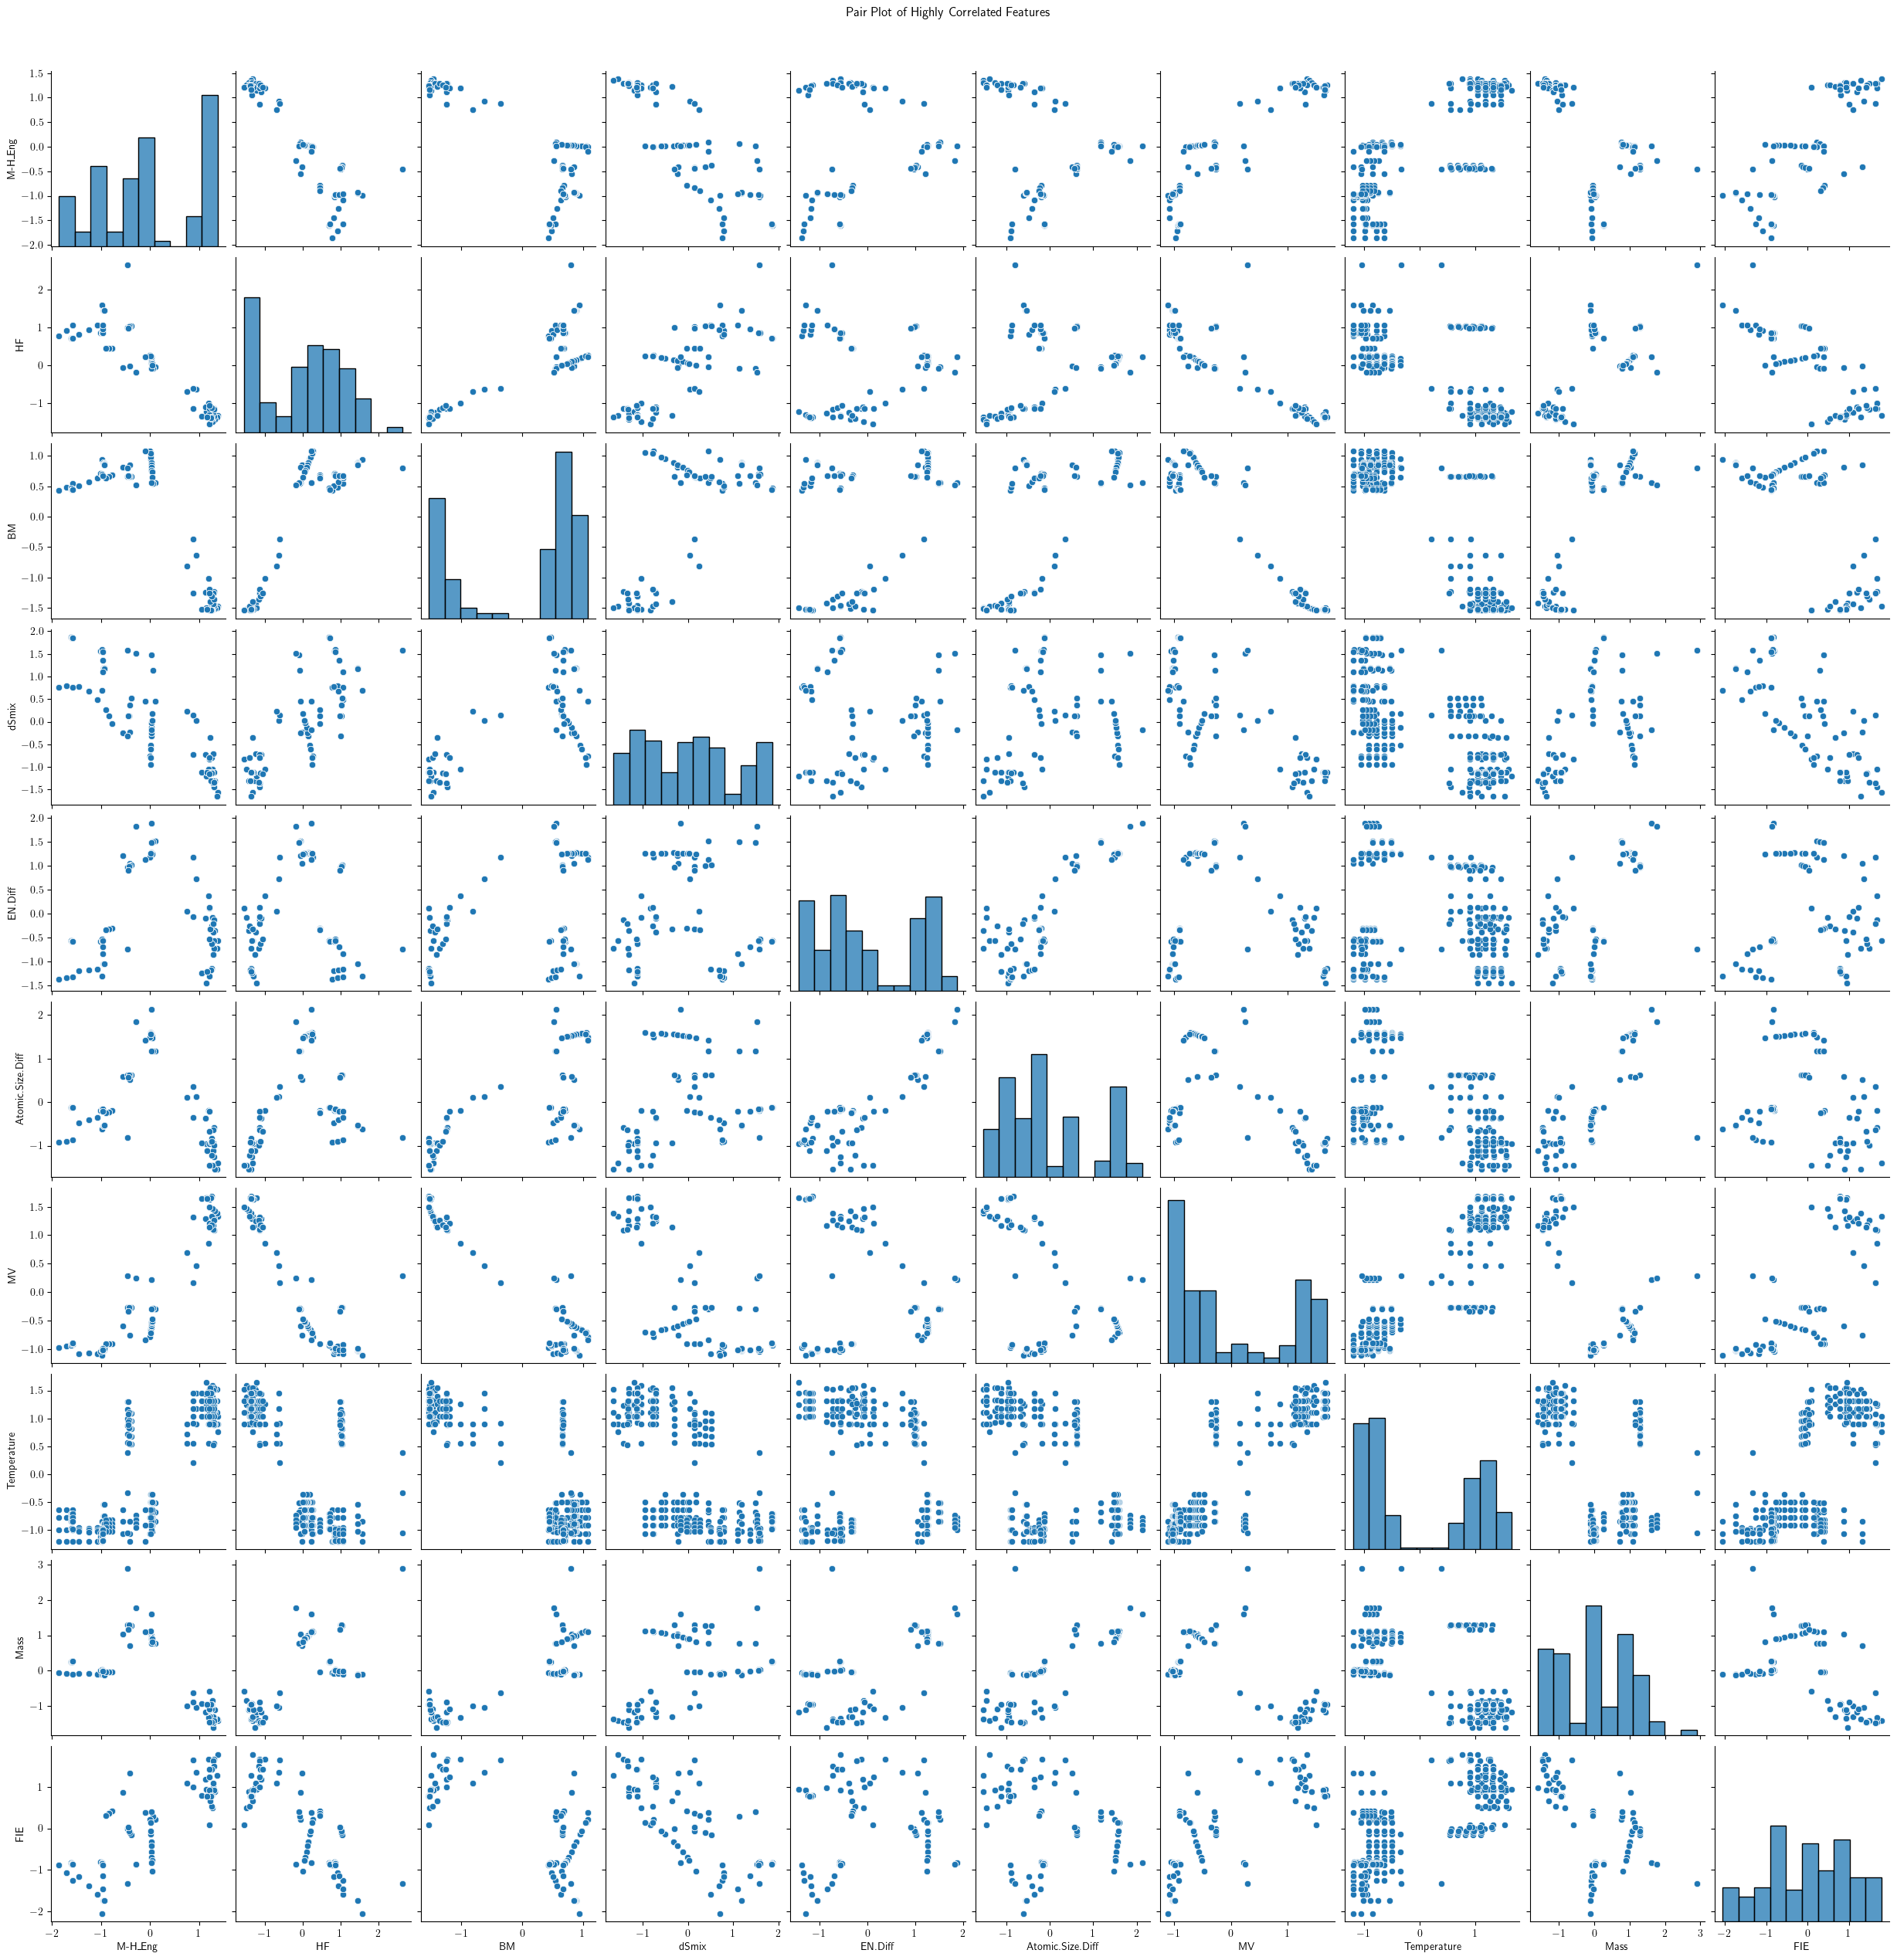

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract all unique features from the correlated_features set
all_correlated_feature_names = set()
for feature_pair in correlated_features:
    all_correlated_feature_names.add(feature_pair[0])
    all_correlated_feature_names.add(feature_pair[1])

# Convert to a list for consistent ordering
all_correlated_feature_names_list = list(all_correlated_feature_names)

# Create a DataFrame with only the highly correlated features
X_correlated = X[all_correlated_feature_names_list]

# Generate the pair plot
plt.figure(figsize=(15, 15)) # Adjust figure size if needed
sns.pairplot(X_correlated)
plt.suptitle('Pair Plot of Highly Correlated Features', y=1.02) # Add a title
plt.show()

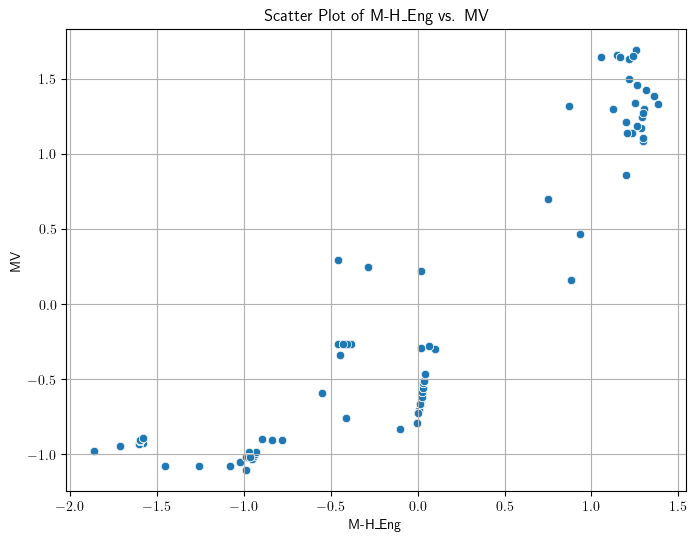

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['M-H_Eng'], y=X['MV'])
plt.title('Scatter Plot of M-H_Eng vs. MV')
plt.xlabel('M-H_Eng')
plt.ylabel('MV')
plt.grid(True)
plt.show()

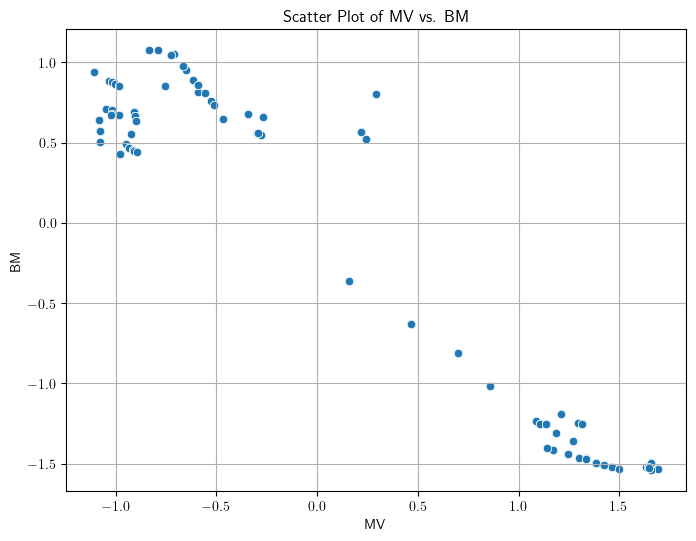

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X['MV'], y=X['BM'])
plt.title('Scatter Plot of MV vs. BM')
plt.xlabel('MV')
plt.ylabel('BM')
plt.grid(True)
plt.show()

In [34]:
# Dataset Overview
# Total points (unique composition–temperature pairs)
# Number of unique compositions
# This gives an overview of dataset diversity and coverage.
Vant_Hoff_Points = len(data.drop_duplicates(['composition_final', 'Temperature']))
Unique_Compositions = len(data['composition_final'].unique())
total = data.shape[0]
print("No of Van't Hoff Plot data points:", Vant_Hoff_Points, "; No of unique composition:", Unique_Compositions)

No of Van't Hoff Plot data points: 293 ; No of unique composition: 77


# Step 3: Hyperparameter Optimization (Grid Search)
### Perform a GridSearchCV to find the best combination of:
### alpha (regularization strength)
### kernel type (linear, rbf, poly)
### gamma (kernel coefficient)
### The best estimator (model configuration) is printed.

In [33]:
param_grid = {
    'alpha': [0.005, 0.001, 0.05, 0.01, 0.5, 0.1, 1.0, 5],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': [0.005, 0.001, 0.05, 0.01, 0.5, 0.1, 1.0, 5]
}
grid = GridSearchCV(KernelRidge(), param_grid, cv=5)
grid.fit(X_train, y_train)
print(grid.best_estimator_)

mae_train = mean_absolute_error(y_train, grid.predict(X_train))
mae_test = mean_absolute_error(y_test, grid.predict(X_test))
score_rr = grid.score(X_test, y_test)

print("MSE_train: %0.2f" % mae_train, "MAE_Test: %0.2f" % mae_test, grid.best_params_)

KernelRidge(alpha=0.001, gamma=0.1, kernel='rbf')
MSE_train: 0.09 MAE_Test: 0.11 {'alpha': 0.001, 'gamma': 0.1, 'kernel': 'rbf'}


# Step 4: Train and Evaluate the Optimized Model
### Train the Kernel Ridge Regression (KRR) model using best hyperparameters.
### MAE (Mean Absolute Error) for train and test data
### R2 Score (model fit accuracy)
### Parity Plot to visualize how well predicted values match experimental ones:
### Blue = training data
### Red = validation data



In [48]:
X_train

,Temperature,CR,Mass,FIE,BM,HF,MV,M-H_Bond,M-H_Eng,formation_H,vol_H,vol_diff,EN.Diff,Atomic.Size.Diff,dSmix
175,-0.956513,-0.860243,1.774794,-0.868478,0.522932,-0.179091,0.244376,-0.583409,-0.286460,-0.675223,-0.816895,-0.043766,1.830838,1.839926,1.515196
213,-0.886576,-0.095506,-0.113930,-1.739039,0.863384,1.449405,-1.001440,1.048901,-0.935393,0.176533,-0.347523,0.662733,-1.051843,-0.534948,1.178400
10,0.896816,0.358976,-1.100248,0.882844,-1.510940,-1.425096,1.424221,-0.380698,1.312339,-0.073927,0.838634,0.610594,-0.349449,-1.531292,-1.309711
87,1.456311,-0.638872,-0.959033,0.785076,-1.534195,-1.363599,1.691497,-0.348831,1.258265,-1.087239,0.672633,0.477284,-1.150633,-0.829668,-1.121397
152,-1.026450,-0.082090,0.892259,-0.769435,0.736412,0.053152,-0.514484,-0.715304,0.034613,-0.109298,-0.144016,0.231825,1.252919,1.499571,0.024400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,-0.921544,-0.114910,0.815055,-1.023632,0.649693,-0.000587,-0.468961,-0.702203,0.041896,-0.102606,0.392533,0.260349,1.246991,1.471050,0.172882
123,-0.494929,-0.036809,1.055454,-0.138194,0.954078,0.189423,-0.649333,-0.750358,0.017232,-0.100694,-1.412806,0.173169,1.264773,1.566121,-0.518747
15,1.526248,0.593763,-0.582680,0.092199,-1.534195,-1.551816,1.500460,-0.357683,1.215779,0.566562,0.896334,0.641065,0.112887,-1.453334,-0.833388
125,-0.774677,-0.036809,1.055454,-0.138194,0.954078,0.189423,-0.649333,-0.750358,0.017232,-0.100694,-1.412806,0.173169,1.264773,1.566121,-0.518747


In [57]:
print(X_train.describe())

       Temperature          CR        Mass         FIE          BM  \
count   234.000000  234.000000  234.000000  234.000000  234.000000   
mean      0.028133   -0.015295    0.015350    0.017344   -0.016486   
std       1.000864    1.022663    1.015588    0.998646    1.021378   
min      -1.201292   -4.085221   -1.602547   -2.050621   -1.541171   
25%      -0.886576   -0.103892   -0.959033   -0.832772   -1.253835   
50%      -0.508917    0.112449   -0.046311    0.092199    0.563210   
75%       1.094388    0.476370    0.973856    0.874768    0.760597   
max       1.652135    1.759317    2.895532    1.781885    1.076224   

               HF          MV    M-H_Bond     M-H_Eng  formation_H  \
count  234.000000  234.000000  234.000000  234.000000   234.000000   
mean    -0.023803    0.036040   -0.049791    0.048603    -0.050711   
std      1.021437    1.011590    0.971366    0.987419     0.982229   
min     -1.551816   -1.107161   -0.775144   -1.860540    -1.933258   
25%     -1.143924  

In [49]:
len(X_test)

59

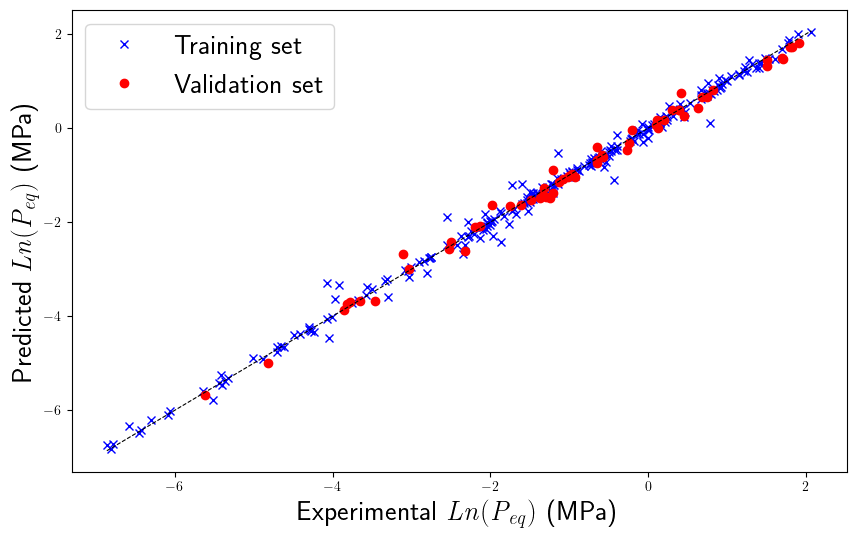

In [35]:
kr = KernelRidge(kernel='rbf', alpha=0.001, gamma=0.1)
kr.fit(X_train, y_train)
y_train_pred = kr.predict(X_train)
y_pred = kr.predict(X_test)

plt.figure(figsize=(10,6))
plt.plot(y_train, y_train_pred, 'xb', label='Training set')
plt.plot(y_test, y_pred, 'or', label='Validation set')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--', lw=0.8, color='black')
plt.legend(loc='upper left', fontsize=20)
plt.xlabel('Experimental $\\it{Ln(P_{eq})}$ (MPa)', fontsize=20)
plt.ylabel('Predicted $\\it{Ln(P_{eq})}$ (MPa)', fontsize=20)
#plt.savefig('OUTPUT/KRR_ML_EXP.png', format='png', dpi=800, bbox_inches='tight')
plt.show()

In [44]:
import joblib

# Save the model
joblib.dump(kr, 'KRR_hydrogen_model.pkl')

# Save the scaler (ESSENTIAL: you must scale new data exactly like the old data)
joblib.dump(scaler, 'material_scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!


In [53]:
prediction = kr.predict(X_test.iloc[[0]])
print(f"Predicted Pressure: {np.exp(prediction)[0]:.4f} MPa")

Predicted Pressure: 1.4698 MPa


In [55]:
from scipy.stats import linregress

# 1. Prepare 1/T and Ln(P)
inv_T = 1 / temp_range  # temp_range from our previous sweep
ln_P = prediction      # predictions from the model

# 2. Linear Regression (Van't Hoff Plot)
slope, intercept, r_value, p_value, std_err = linregress(inv_T, ln_P)

# 3. Extract Constants (R = 8.314 J/mol*K)
R = 8.314
delta_H = slope * R / 1000  # in kJ/mol H2
delta_S = intercept * R     # in J/mol K

print(f"Predicted Enthalpy (ΔH): {delta_H:.2f} kJ/mol")
print(f"Predicted Entropy (ΔS): {delta_S:.2f} J/mol·K")

Predicted Enthalpy (ΔH): 0.00 kJ/mol
Predicted Entropy (ΔS): 3.20 J/mol·K


In [60]:
X_test

,Temperature,CR,Mass,FIE,BM,HF,MV,M-H_Bond,M-H_Eng,formation_H,vol_H,vol_diff,EN.Diff,Atomic.Size.Diff,dSmix
286,-1.194299,0.396273,-0.005287,-1.151155,0.679647,0.961159,-1.019553,2.199131,-0.973741,1.588477,0.349113,-0.272551,-0.702128,-0.211707,1.365244
127,-0.494929,-0.031778,1.073587,-0.068056,0.978263,0.204564,-0.664316,-0.754253,0.015301,-0.099738,-1.553782,0.166652,1.264773,1.577530,-0.603705
181,-0.781671,0.683201,-0.077293,-1.075492,0.488980,0.922328,-0.947985,-0.008383,-1.712281,0.050347,-0.361888,-2.672887,-1.348212,-0.892415,0.789061
59,-1.061418,-3.026647,0.713223,1.321950,0.854012,-0.020015,-0.756640,-0.703620,-0.410773,0.646862,-0.142215,0.478300,1.045461,0.520340,-0.224202
253,1.085646,1.197503,1.161158,0.036938,0.675601,0.980959,-0.341823,-0.608195,-0.446969,-1.182834,-0.628010,0.341859,0.905179,0.567876,0.131873
244,0.826879,1.214274,1.283731,-0.107588,0.657578,1.031042,-0.268449,-0.605539,-0.408070,-1.374025,-1.008743,0.257641,1.004957,0.615411,0.370051
111,1.316438,0.102705,-1.451537,1.426094,-1.311936,-1.107550,1.187441,-0.423188,1.260307,-0.783245,0.752459,0.589095,-0.626060,-0.892415,-1.128357
98,1.036690,-2.055984,-0.943794,0.774449,-1.529544,-1.354282,1.646988,-0.350602,1.165845,-1.087239,0.659785,0.472629,-1.210894,-1.120585,-1.121397
65,0.721974,0.173292,-1.007565,1.088157,-0.811082,-0.683223,0.698678,0.263374,0.750695,0.340001,0.579551,0.557355,0.051637,0.102028,0.235196
184,-0.641797,0.528358,-0.091194,-1.259550,0.551769,1.067148,-0.923704,-0.108234,-1.578643,-0.224012,-0.422887,-2.035794,-1.324502,-0.871499,0.757332


In [63]:
results = data.loc[X_test.index, ['composition_final']].copy()
results['Actual_LnP'] = y_test
results['Predicted_LnP'] = kr.predict(X_test)

results.head()

,composition_final,Actual_LnP,Predicted_LnP
286,Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03,0.3042,0.385097
127,Al0.03La0.17Ni0.8,0.1194,0.168113
181,Mn0.33Ti0.33V0.33,-0.2029,-0.040220
59,Co0.75Mg0.12Nd0.12,0.1227,0.011741
253,Co0.5Ti0.05Zr0.45,-3.6543,-3.670739


In [65]:
# 1. Reverse the scaling for X_test to get original physical values
X_test_raw = scaler.inverse_transform(X_test)
X_test_raw_df = pd.DataFrame(X_test_raw, columns=Features, index=X_test.index)

results = pd.DataFrame(index=X_test.index)
results['Composition'] = data.loc[X_test.index, 'composition_final']
results['Temp_Kelvin'] = X_test_raw_df['Temperature']
results['Actual_LnP'] = y_test
results['Predicted_LnP'] = kr.predict(X_test)

results.head()

,Composition,Temp_Kelvin,Actual_LnP,Predicted_LnP
286,Cr0.4Fe0.12Mn0.09Ti0.34Zr0.03,274.0,0.3042,0.385097
127,Al0.03La0.17Ni0.8,374.0,0.1194,0.168113
181,Mn0.33Ti0.33V0.33,333.0,-0.2029,-0.040220
59,Co0.75Mg0.12Nd0.12,293.0,0.1227,0.011741
253,Co0.5Ti0.05Zr0.45,600.0,-3.6543,-3.670739


In [66]:
# Example: Temperature range [-1.2, 1.6], CR range [-4.0, 1.7] in scaled units
import numpy as np

# Create 10 "random" material samples
# We'll create a matrix of random numbers between 0 and 1, then scale them to your feature space
random_samples = np.random.uniform(-1, 1, size=(10, len(Features)))
df_random = pd.DataFrame(random_samples, columns=Features)
random_preds = kr.predict(df_random)

# 4. View Results
df_random['Predicted_Ln_P'] = random_preds
df_random.head()

,Temperature,CR,Mass,FIE,BM,HF,MV,M-H_Bond,M-H_Eng,formation_H,vol_H,vol_diff,EN.Diff,Atomic.Size.Diff,dSmix,Predicted_Ln_P
0,0.766385,-0.729130,-0.335753,-0.815752,0.834585,-0.212554,-0.959258,-0.186083,-0.161018,-0.353145,-0.658876,-0.621241,-0.537454,-0.648073,0.782319,2.958015
1,0.406207,-0.478843,-0.578346,-0.324871,0.908577,-0.337505,0.827620,-0.841867,0.348851,-0.028574,-0.088722,0.900347,-0.130507,-0.200283,0.095533,-0.203326
2,0.626055,-0.114157,-0.241835,-0.227695,-0.904185,0.819763,-0.522165,0.203240,-0.839610,-0.665562,-0.484435,-0.709862,-0.222208,-0.827962,-0.801070,0.747006
3,0.777013,0.749368,0.650645,-0.068759,-0.695194,0.426924,0.121666,-0.406879,-0.466627,0.631297,0.555893,0.015972,0.936802,0.307106,0.816795,-0.063532
4,-0.990020,0.032586,-0.880935,-0.153831,0.934230,-0.818355,0.957804,-0.348807,0.315503,-0.296960,0.190530,-0.877441,0.028596,-0.670588,-0.112687,-6.627155


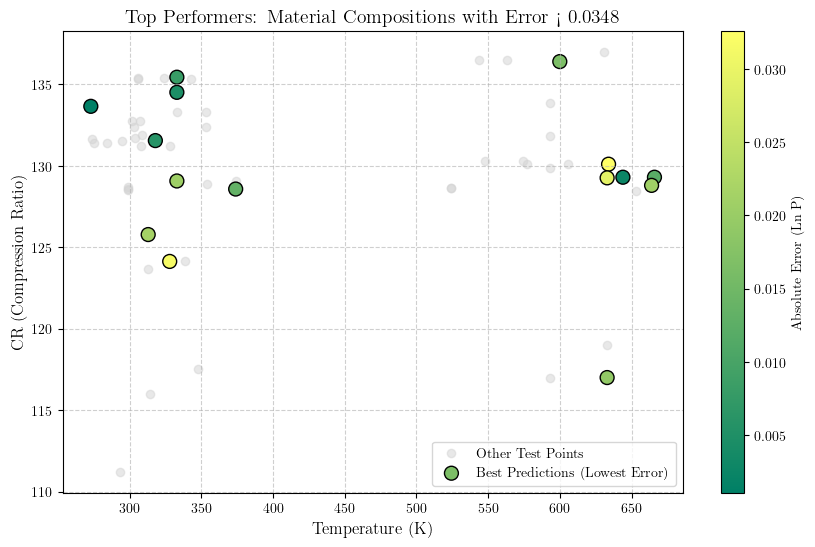

In [67]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

y_test_pred = kr.predict(X_test)
errors = np.abs(y_test - y_test_pred)

X_test_raw = scaler.inverse_transform(X_test)
X_test_raw_df = pd.DataFrame(X_test_raw, columns=Features, index=X_test.index)

analysis_df = X_test_raw_df[['Temperature', 'CR']].copy()
analysis_df['Error'] = errors
analysis_df['Composition'] = data.loc[X_test.index, 'composition_final']

threshold = analysis_df['Error'].quantile(0.25)
best_preds = analysis_df[analysis_df['Error'] <= threshold]

plt.figure(figsize=(10, 6))
plt.scatter(analysis_df['Temperature'], analysis_df['CR'],
            c='lightgrey', alpha=0.5, label='Other Test Points')

# Plot the best predictions in green
scatter = plt.scatter(best_preds['Temperature'], best_preds['CR'],
            c=best_preds['Error'], cmap='summer', s=100, edgecolor='black',
            label='Best Predictions (Lowest Error)')

plt.colorbar(scatter, label='Absolute Error (Ln P)')
plt.xlabel('Temperature (K)', fontsize=12)
plt.ylabel('CR (Compression Ratio)', fontsize=12)
plt.title(f'Top Performers: Material Compositions with Error < {threshold:.4f}', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [68]:
print("Compositions with the highest accuracy:")
print(best_preds[['Composition', 'Temperature', 'CR', 'Error']].sort_values(by='Error'))

Compositions with the highest accuracy:
                                Composition  Temperature        CR     Error
191                      Cr0.36Mn0.29Ti0.36        273.0  133.6535  0.001058
36            Al0.1Ga0.02In0.04Mg0.82Zn0.02        644.0  129.3000  0.002487
157                   La0.289Ni0.675Si0.036        333.0  134.5120  0.004594
228                     Fe0.425Mn0.075Ti0.5        318.0  131.5500  0.005747
269       Cr0.257Fe0.064Mn0.32Ti0.23Zr0.125        333.0  135.4408  0.008026
35            Al0.1Ga0.02In0.04Mg0.82Zn0.02        666.0  129.3000  0.012122
154                      Al0.17La0.17Ni0.67        374.0  128.5743  0.013297
253                       Co0.5Ti0.05Zr0.45        600.0  136.4000  0.016439
80                        Ce0.05Mg0.9Sm0.05        633.0  117.0000  0.019094
129                       Al0.03La0.17Ni0.8        333.0  129.0700  0.020570
19                               Al0.1Mg0.9        664.0  128.8000  0.020798
167                      Ce0.02La0.1

   k  mean_mae   std_mae  mean_mse  std_mse   mean_r2    std_r2
0  2  0.303845  0.049385  0.275217  0.09887  0.924508  0.035928
1  3  0.202493  0.032725  0.104133  0.03606  0.973137  0.006793


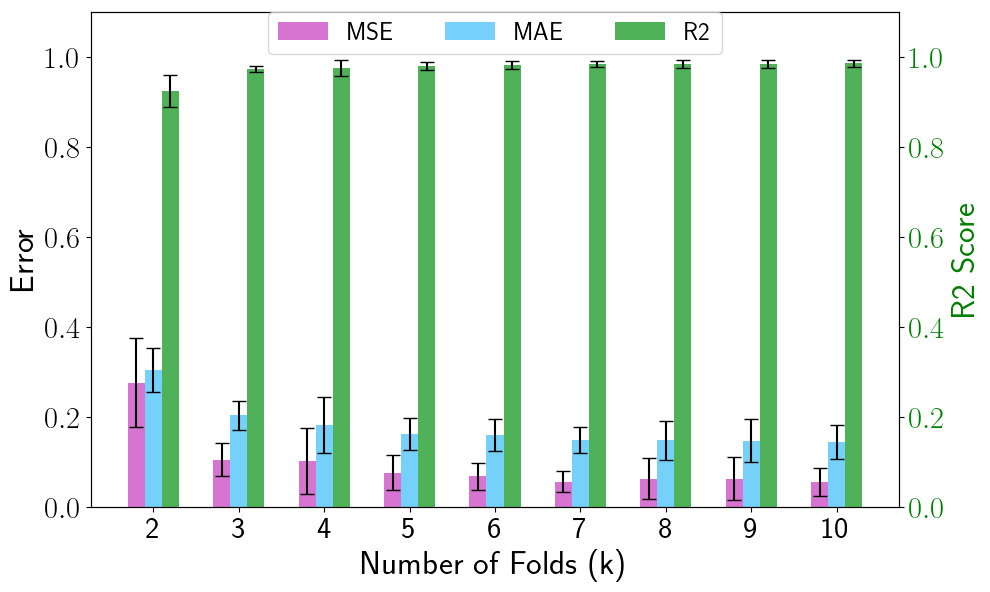

In [36]:
# Evaluate Model for Different K Values
# Run multiple K-fold validations (for K = 2 → 10)
# to see how error metrics change with the number of folds.
# Calculates and stores:
# Mean and standard deviation of MAE, MSE, R²
# Results are stored in a DataFrame (results_df).
# Define metrics and storage

# Visualize Cross-Validation Metrics
# Create a bar plot showing:
# MAE and MSE (left y-axis)
# R² (right y-axis)
# for each k value.
# This helps compare model stability as the number of folds varies.

scoring = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}
k_values = np.arange(2,11,1)
results = []

# Iterate over different k values
for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # Run cross-validation once for all metrics
    cv_results = cross_validate(kr, X, y, cv=kf, scoring=scoring)

    # Compute mean and std for each metric
    mean_mae = -np.mean(cv_results['test_mae'])
    std_mae = np.std(cv_results['test_mae'])
    mean_mse = -np.mean(cv_results['test_mse'])
    std_mse = np.std(cv_results['test_mse'])
    mean_r2 = np.mean(cv_results['test_r2'])
    std_r2 = np.std(cv_results['test_r2'])

    # Store results in a structured format
    results.append({
        'k': k,
        'mean_mae': mean_mae,
        'std_mae': std_mae,
        'mean_mse': mean_mse,
        'std_mse': std_mse,
        'mean_r2': mean_r2,
        'std_r2': std_r2
    })

# Convert to DataFrame for easy plotting and analysis
results_df = pd.DataFrame(results)
print(results_df.head(2))

fig, ax1 = plt.subplots(figsize=(10, 6))
plt.xticks(k_values, k_values, fontsize=22)
# Bar plot with error bars for Mean Absolute Error (MAE)
bar_width = 0.2
ax1.set_ylim(0, 1.1)
k_values_shifted = k_values - bar_width
ax1.bar(k_values_shifted, results_df['mean_mse'], width=bar_width, yerr=results_df['std_mse'], capsize=5, color='#C738BD', alpha=0.7, label='MSE')
ax1.bar(k_values, results_df['mean_mae'], width=bar_width, yerr=results_df['std_mae'], capsize=5, color='#3ABEF9', alpha=0.7, label='MAE')
ax1.set_xlabel('Number of Folds (k)', fontsize=24)
ax1.set_ylabel('Error', fontsize=24)
ax1.tick_params(axis='y', labelsize=22)

ax2 = ax1.twinx()
ax2.set_ylim(0, 1.2)
ax2.bar(k_values + bar_width, results_df['mean_r2'], width=bar_width, yerr=results_df['std_r2'], capsize=5, color='#059212', alpha=0.7, label='R2')
ax2.set_ylabel('R2 Score', color='g', fontsize=24)
ax2.tick_params(axis='y', labelcolor='g', labelsize=22)
plt.ylim(0,1.1)

# Add legend
fig.legend(loc='upper center',shadow=False, ncol=3, fontsize=18)

plt.tight_layout()
#plt.savefig('OUTPUT/KRR_ML_K-fold.png',format='png',dpi=800, bbox_inches='tight')
plt.show()

# ***#Step 5: SHAP (Feature Importance) Analysis***
###Compute SHAP values to explain model predictions
###Generate SHAP summary plots and bar plots
###Rank features by mean absolute SHAP value (importance)
###This provides insight into which physical or chemical descriptors most strongly influence equilibrium pressure



In [38]:
import shap
# SHAP Explainer
model=KernelRidge(kernel='rbf', alpha = 0.001, gamma = 0.1)
model.fit(X_train, y_train)
explainer = shap.KernelExplainer(model.predict,X_train)
shap_values = explainer(X_test)


  0%|          | 0/59 [00:00<?, ?it/s]

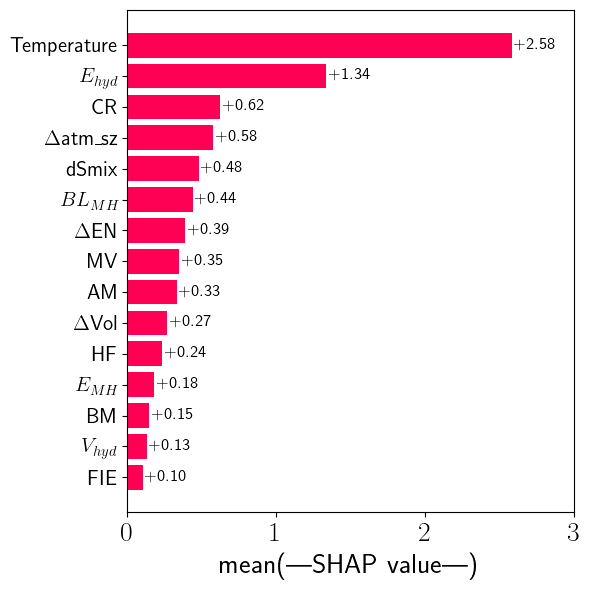

In [39]:
mean_shap = np.abs(shap_values.values).mean(axis=0)
feature_names = X_test.columns
# Sort by importance
sorted_idx = np.argsort(mean_shap)[::-1]
sorted_means = mean_shap[sorted_idx]
sorted_features = [r'Temperature', r'$E_{hyd}$', r'CR', r'$\Delta$atm_sz', r'dSmix',
            r'$BL_{MH}$', r'$\Delta$EN', r'MV', r'AM', r'$\Delta$Vol', r'HF',
             r'$E_{MH}$', r'BM', r'$V_{hyd}$', r'FIE']
# Bar plot manually (instead of shap.plots.bar)
fig, ax = plt.subplots(figsize=(6, 6))
plt.locator_params(nbins=5)
ax.barh(range(len(sorted_means)), sorted_means, align="center",color= "#ff0055")
ax.set_yticks(range(len(sorted_means)))
ax.set_yticklabels(sorted_features,fontsize=15)
ax.invert_yaxis()  # most important at top
ax.set_xlabel("mean(|SHAP value|)",fontsize=20)
# Add SHAP values at the end of bars
for i, v in enumerate(sorted_means):
    ax.text(v + 0.01, i, f"{ v:+.2f}", va="center", fontsize=12)
plt.xlim(0,3)
plt.xticks(fontsize=20)
plt.tight_layout()

#plt.savefig('OUTPUT/SHAP_FI.png',format='png',dpi=800, bbox_inches='tight')
plt.show()

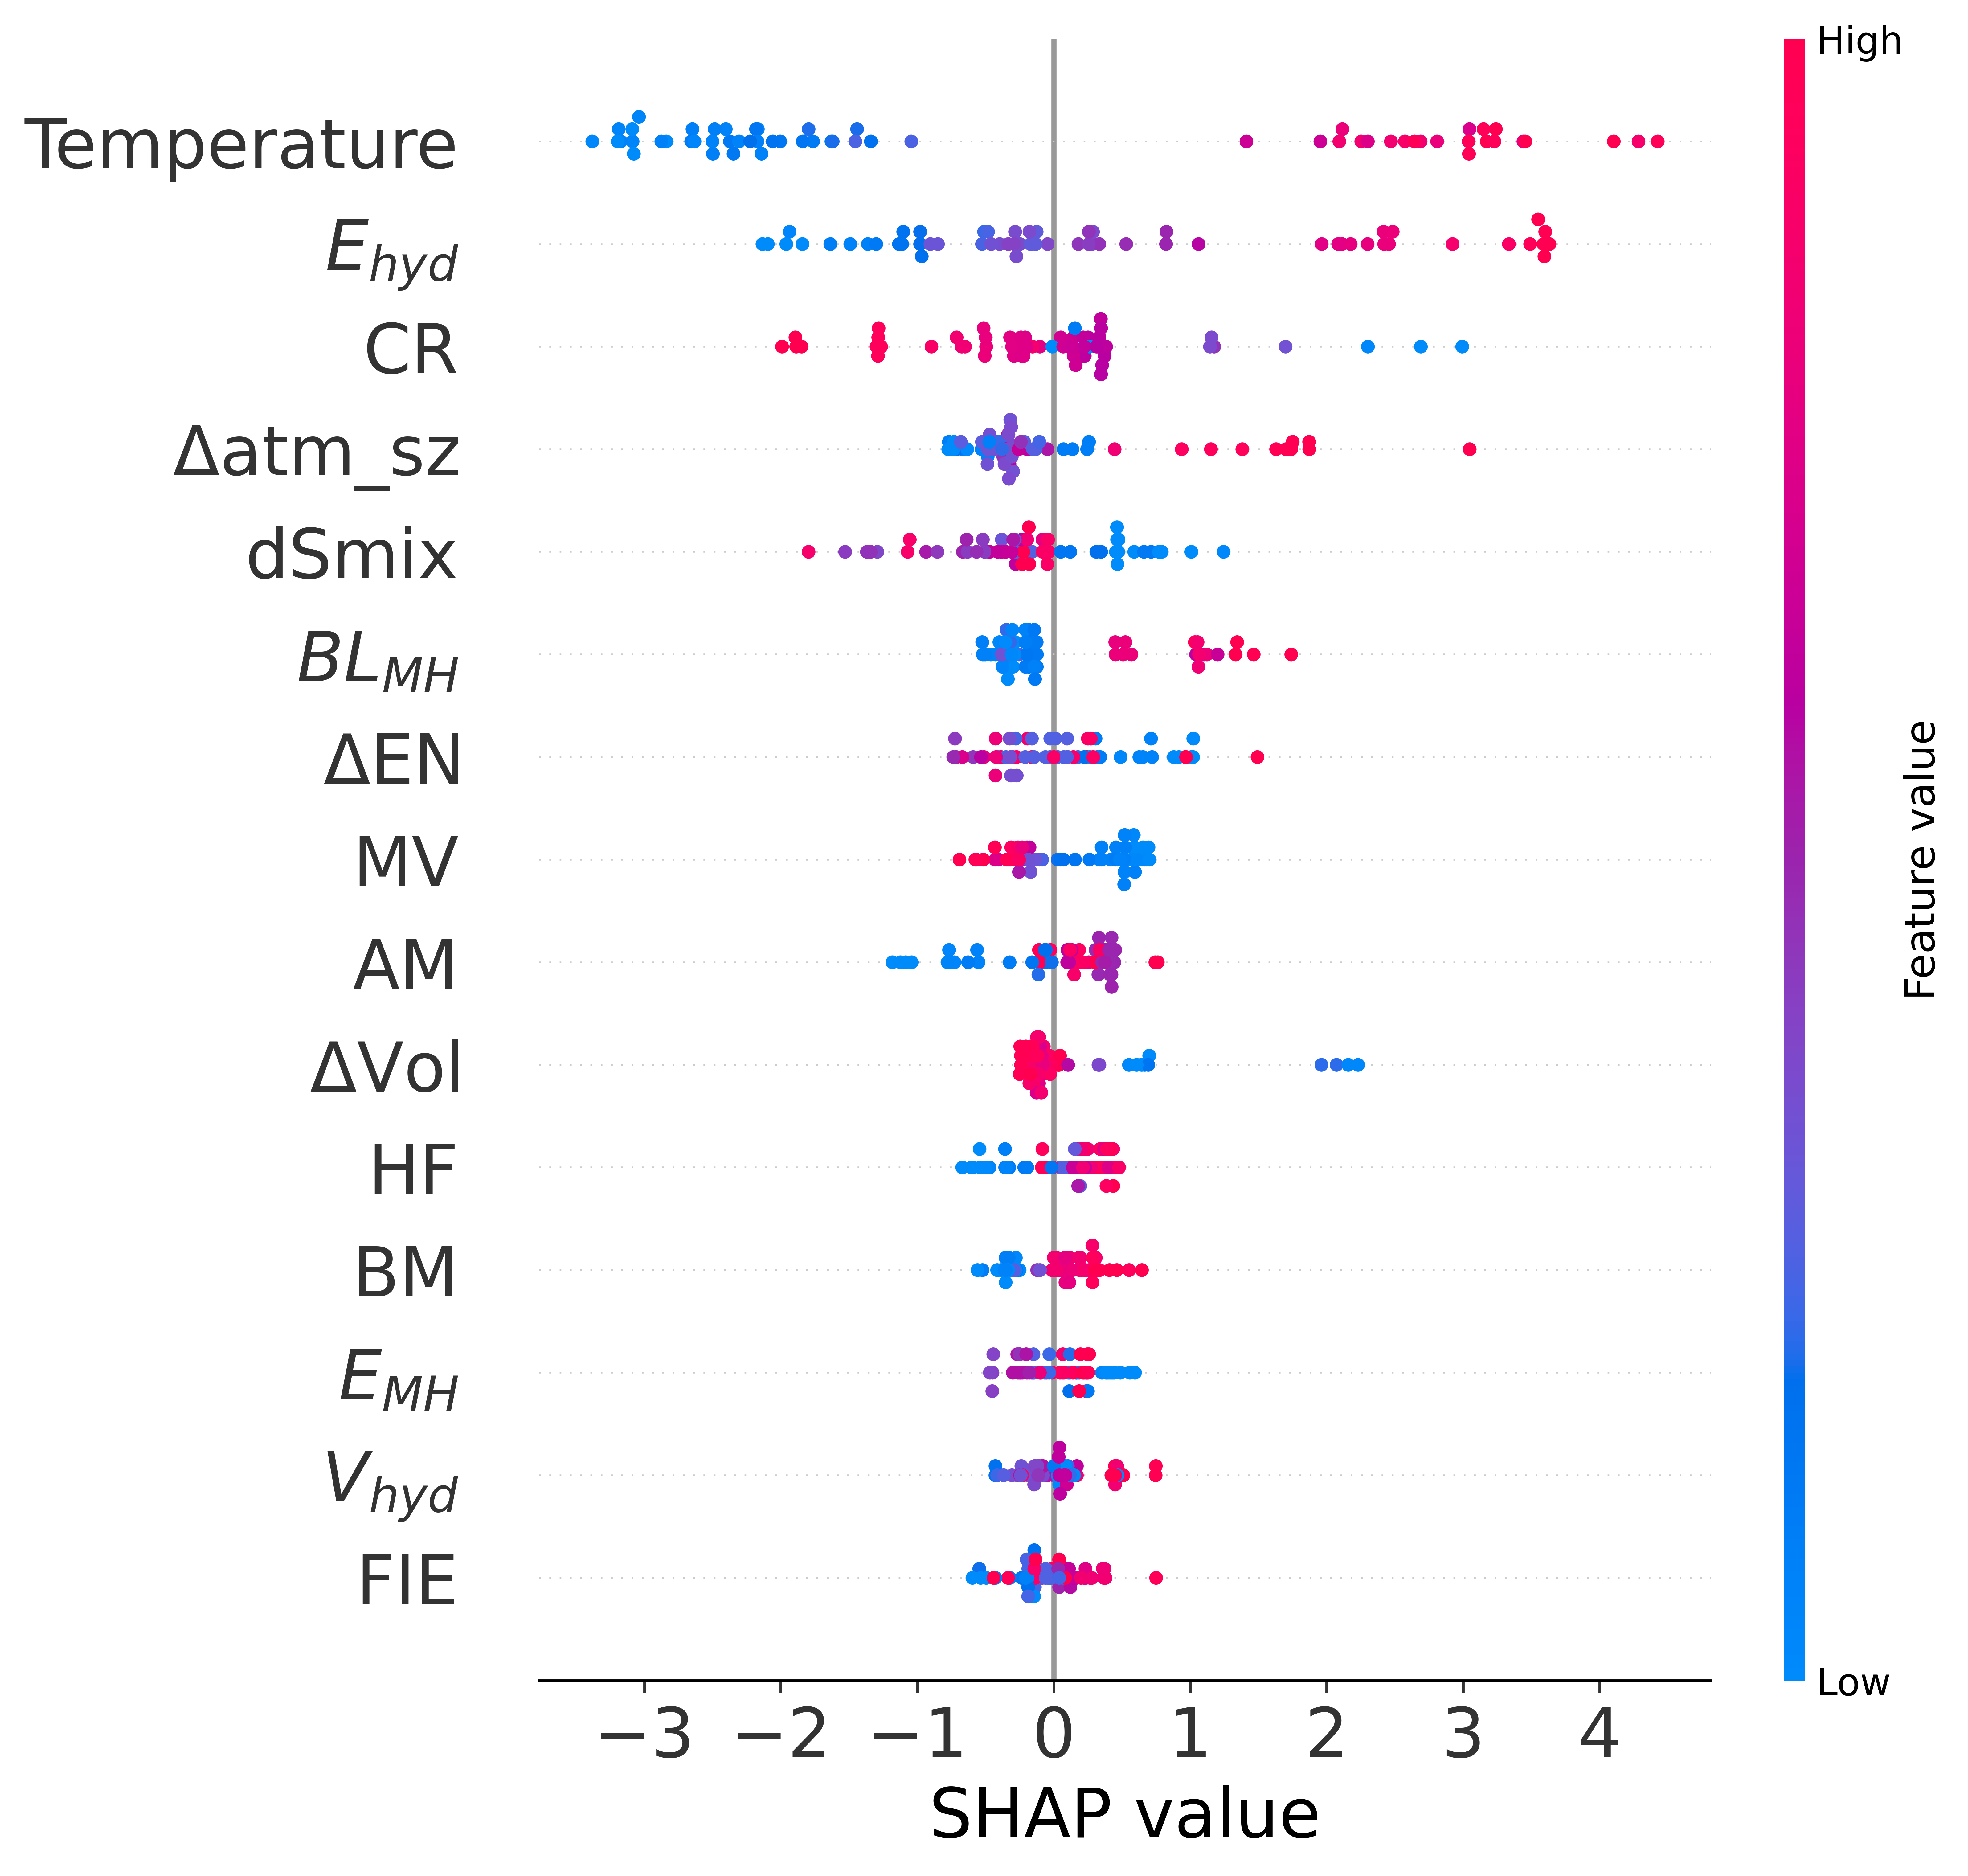

# **#Step 7: Leave-One-Composition-Out (LOCO) Analysis**
### Iteratively removes one composition from training
### train model on n-1 compositions
### Predicts Peq for removed composition using the rest of the data
### Compares predicted vs. experimental P–T relationships
### Estimates ΔH (enthalpy) and ΔS (entropy) via Van’t Hoff fits
### Plots are generated showing both experimental and model-predicted trends for each composition.

In [41]:
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

col1=['Temperature', 'CR',
       'FIE',  'BM', 'HF', 'MV',  'Mass',
    'M-H_Bond', 'M-H_Eng',    'formation_H',
       'vol_H',  'vol_diff', 'EN.Diff',
       'Atomic.Size.Diff', 'dSmix']
dff = []
unique_entries = data.drop_duplicates(['composition_final'])
test=data

loco_results = [] # List to store LOCO analysis results

for xx in range(0,len(unique_entries)):
    q=unique_entries[xx:xx+1]
    compostion = q['composition_final']
    com=compostion.values[0]
    print(f"Analyzing composition: {com}") # Added print statement
    TEST=data[(data["composition_final"]==com)]
    TRAIN= data.drop(TEST.index)

    X_train1 = TRAIN[col1]
    y_train1 = TRAIN["Ln(P)_Mpa"]

    #Input and Target
    X_test1 = TEST[col1]
    y_test1 = TEST["Ln(P)_Mpa"]



    clf1=KernelRidge(kernel='rbf', alpha = 0.001, gamma = 0.1)
    clf1.fit(X_train1, y_train1)
    TEST['ML_KRR']=clf1.predict(X_test1)

    plt.figure(figsize=(10,6))
    plt.rcParams['font.family'] = 'Serif'
    plt.locator_params(nbins=4)
    plt.xticks(fontsize=25,)
    plt.yticks(fontsize=25)
    slope, intercept, _, _, _ = linregress(1000/(TEST['Temperature_1']),np.log(10*np.exp(TEST['Ln(P)_Mpa'])))
    sl1= slope*8.314
    in1= intercept*8.314
    plt.scatter(1000/(TEST['Temperature_1']),np.log(10*np.exp(TEST['Ln(P)_Mpa'])), marker='o',color='black')
    plt.plot((1000/(TEST['Temperature_1'])), slope*(1000/(TEST['Temperature_1'])) + intercept, 'ko-', linewidth=2, markersize=0, color='black', label=f'Expt. (ΔH: {sl1:.2f} ; ΔS: - {in1:.2f} )')

    slope1, intercept1, _, _, _ = linregress(1000/(TEST['Temperature_1']),np.log(10*np.exp(TEST['ML_KRR'])))
    sl2= slope1*8.314
    in2= intercept1*8.314
    plt.scatter(1000/(TEST['Temperature_1']),np.log(10*np.exp(TEST['ML_KRR'])),marker='^',color='red')
    plt.plot(1000/(TEST['Temperature_1']), slope1*(1000/(TEST['Temperature_1'])) + intercept1, 'r^-', linewidth=2, markersize=0, label=f'EquiP (ΔH: {sl2:.2f} ({np.abs(np.abs(sl1)-np.abs(sl2)):.2f}); ΔS: - {in2:.2f} ({in1-in2:.2f})) ')

    plt.xlabel(r'$1000/T$ (K$^{-1}$)', fontsize=25)
    plt.ylabel(r'$\ln(P)$ (bar)', fontsize=25)
    plt.legend(loc="upper right",frameon=False,fontsize=20)
    plt.tight_layout()
    plt.show()

    loco_results.append({
        'composition': com,
        'Exp_Enthalpy': sl1,
        'Exp_Entropy': in1,
        'ML_Enthalpy': sl2,
        'ML_Entropy': in2
    })

Va = pd.DataFrame(loco_results)


Analyzing composition: Mg0.95Sn0.03Zn0.02


RuntimeError: latex was not able to process the following string:
b'Expt. (\\u0394H: -66.27 ; \\u0394S: - 122.46 )'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpth7th0yz c9796783f5d82ecdc48046a9743e08ad.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./c9796783f5d82ecdc48046a9743e08ad.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/l

Error in callback <function _draw_all_if_interactive at 0x7c4f0b2e6840> (for post_execute):


RuntimeError: latex was not able to process the following string:
b'Expt. (\\u0394H: -66.27 ; \\u0394S: - 122.46 )'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpclacyb_i c9796783f5d82ecdc48046a9743e08ad.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./c9796783f5d82ecdc48046a9743e08ad.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/l

RuntimeError: latex was not able to process the following string:
b'Expt. (\\u0394H: -66.27 ; \\u0394S: - 122.46 )'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp0zb3uafi c9796783f5d82ecdc48046a9743e08ad.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.22 (TeX Live 2022/dev/Debian) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./c9796783f5d82ecdc48046a9743e08ad.tex
LaTeX2e <2021-11-15> patch level 1
L3 programming layer <2022-01-21>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2021/10/04 v1.4n Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texmf/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex/l

<Figure size 1000x600 with 1 Axes>

In [42]:
display(Va)

NameError: name 'Va' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Exp_Enthalpy', y='ML_Enthalpy', data=Va, s=100, hue='composition', palette='viridis', legend='full')
plt.plot([Va['Exp_Enthalpy'].min(), Va['Exp_Enthalpy'].max()],
         [Va['Exp_Enthalpy'].min(), Va['Exp_Enthalpy'].max()],
         'k--', lw=2, label='Perfect Fit')
plt.title('Experimental vs. Predicted Enthalpy (ΔH)')
plt.xlabel('Experimental ΔH (kJ/mol)')
plt.ylabel('Predicted ΔH (kJ/mol)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Exp_Entropy', y='ML_Entropy', data=Va, s=100, hue='composition', palette='viridis', legend='full')
plt.plot([Va['Exp_Entropy'].min(), Va['Exp_Entropy'].max()],
         [Va['Exp_Entropy'].min(), Va['Exp_Entropy'].max()],
         'k--', lw=2, label='Perfect Fit')
plt.title('Experimental vs. Predicted Entropy (ΔS)')
plt.xlabel('Experimental ΔS (J/(mol·K))')
plt.ylabel('Predicted ΔS (J/(mol·K))')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Va['Delta_Enthalpy'] = np.abs(Va['Exp_Enthalpy'] - Va['ML_Enthalpy'])
Va['Delta_Entropy'] = np.abs(Va['Exp_Entropy'] - Va['ML_Entropy'])

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(Va['Delta_Enthalpy'], bins=15, kde=True)
plt.title('Distribution of Absolute ΔH Difference')
plt.xlabel('Absolute ΔH Difference (kJ/mol)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(Va['Delta_Entropy'], bins=15, kde=True)
plt.title('Distribution of Absolute ΔS Difference')
plt.xlabel('Absolute ΔS Difference (J/(mol·K))')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
import joblib
# Save model to file
joblib.dump(model, "krr_model.pkl")
print("Model saved as krr_model.pkl")

Model saved as krr_model.pkl


In [ ]:
# Load model
loaded_model = joblib.load("krr_model.pkl")

# Test the loaded model
y_pred = loaded_model.predict(X_test)
print("Experiment:", round(y_test.values[0],4))
print("Prediction:", round(y_pred[0],4))

Experiment: 0.3042
Prediction: 0.3851


# **Examples to train multiple ML architectures (Random Forest, CNN, RNN, LSTM, Transformer) for molecular property prediction using open-access datasets.**

In [ ]:
pip install rdkit torch torchvision torchaudio torchtext torch-geometric scikit-learn pandas numpy tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.0 MB/s eta 0:00:00


In [ ]:
#Load & Preprocess Data (QM9 via PyTorch Geometric)
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
import torch